<a href="https://colab.research.google.com/github/yejinPARK48/michigan_building_detection/blob/main/06_puma_estimation/puma_summary_maps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd

PRED_DIR = '/content/drive/MyDrive/michigan_unet_project/results_9puma/predictions_puma'
PUMAS_9 = ['2600100', '2600802', '2601200', '2601600', '2601701',
           '2601703', '2602903', '2603203', '2603212']

rows, missing = [], []
for code in PUMAS_9:
    f = f'{PRED_DIR}/bg_estimates_puma_{code}.csv'
    if not os.path.exists(f):
        missing.append(code)
        continue
    d = pd.read_csv(f, dtype={'puma': str})
    b = int(d['pred_buildings'].sum())
    a = float(d['area_km2'].sum())
    rows.append({
        'puma': code,                          # 7-digit, ACS PUMS format
        'total_buildings': b,
        'buildings_per_km2': round(b / a, 2),  # density-normalized count
    })

summary = pd.DataFrame(rows).sort_values('puma').reset_index(drop=True)
out = f'{PRED_DIR}/puma_building_summary.csv'
summary.to_csv(out, index=False)

print(summary.to_string(index=False))
print(f'\nReady: {len(rows)}/9   Missing: {missing}')
print('Saved ->', out)

   puma  total_buildings  buildings_per_km2
2600100           113414               5.09
2600802            57275              66.70
2601200            92167              20.60
2601600           118850              17.63
2601701            92344              42.36
2601703            51206             314.07
2602903            64491             360.97
2603203            71185             753.29
2603212            24107             361.63

Ready: 9/9   Missing: []
Saved -> /content/drive/MyDrive/michigan_unet_project/results_9puma/predictions_puma/puma_building_summary.csv


In [6]:
!pip install pystac-client planetary-computer rasterio geopandas shapely pyogrio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 24.4 MB/s eta 0:00:00



[2600100] total 763,023 | covered 402,349 | fallback 360,674 (47.3%) | NAIP images 1202


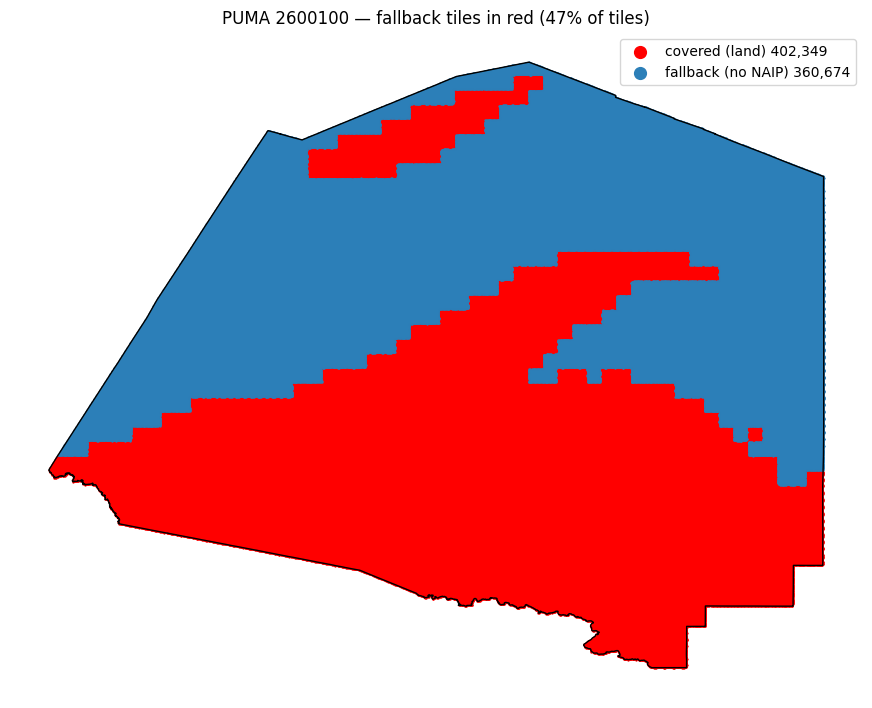

saved -> /content/drive/MyDrive/michigan_unet_project/results_9puma/predictions_puma/fallback_check_2600100.png

[2601600] total 183,351 | covered 116,954 | fallback 66,397 (36.2%) | NAIP images 267


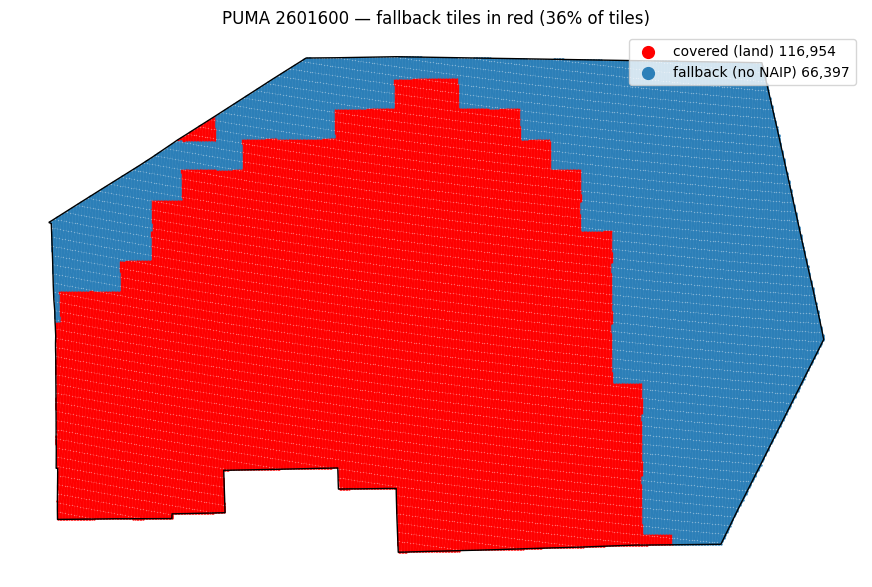

saved -> /content/drive/MyDrive/michigan_unet_project/results_9puma/predictions_puma/fallback_check_2601600.png


In [15]:
import os, zipfile, urllib.request
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer
from shapely.geometry import box, Point, shape as shapely_shape
from shapely.ops import transform as shp_transform
from shapely.prepared import prep
import pystac_client, planetary_computer as pc
from google.colab import userdata
pc.settings.set_subscription_key(userdata.get('PC_KEY'))

BASE_DIR = '/content/drive/MyDrive/michigan_unet_project'
GEO_DIR  = f'{BASE_DIR}/geo'
TILE_SIZE_M, UTM_EPSG, NAIP_YEAR = 256, 26917, 2020

# --- which PUMAs to check ---
CHECK = ['2600100', '2601600']

# --- load PUMA + BG shapefiles (cached) ---
shp_puma = [f'{GEO_DIR}/puma20/{f}' for f in os.listdir(f'{GEO_DIR}/puma20') if f.endswith('.shp')][0]
gdf_puma_all = gpd.read_file(shp_puma)
gcol = next(c for c in gdf_puma_all.columns if c.upper().startswith('GEOID'))
gdf_puma_all[gcol] = gdf_puma_all[gcol].astype(str)

gdf_bg = gpd.read_file(f'{BASE_DIR}/tl_2020_26_bg.shp').to_crs(4326)
gdf_bg = gdf_bg.rename(columns={'GEOID':'bg_geoid'})

def get_naip_items(bbox, max_items=4000):
    cat = pystac_client.Client.open('https://planetarycomputer.microsoft.com/api/stac/v1', modifier=pc.sign_inplace)
    it = cat.search(collections=['naip'], bbox=bbox, datetime=f'{NAIP_YEAR}-01-01/{NAIP_YEAR}-12-31', max_items=max_items).item_collection()
    if len(it)==0:
        it = cat.search(collections=['naip'], bbox=bbox, max_items=max_items).item_collection()
    return list(it)

def build_tiles(puma_geom):
    to_utm = Transformer.from_crs('EPSG:4326', f'EPSG:{UTM_EPSG}', always_xy=True).transform
    to_wgs = Transformer.from_crs(f'EPSG:{UTM_EPSG}', 'EPSG:4326', always_xy=True).transform
    g = shp_transform(to_utm, puma_geom); pg = prep(g)
    minx,miny,maxx,maxy = g.bounds
    rows=[]; x=minx
    while x<maxx:
        y=miny
        while y<maxy:
            cx,cy = x+TILE_SIZE_M/2, y+TILE_SIZE_M/2
            if pg.contains(Point(cx,cy)):
                wcx,wcy = to_wgs(cx,cy); rows.append((wcx,wcy))
            y+=TILE_SIZE_M
        x+=TILE_SIZE_M
    df = pd.DataFrame(rows, columns=['cx','cy'])
    return gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['cx'],df['cy']), crs='EPSG:4326')

for code in CHECK:
    puma_geom = gdf_puma_all[gdf_puma_all[gcol]==code].to_crs(4326).iloc[0].geometry
    gt = build_tiles(puma_geom)

    items = get_naip_items(puma_geom.bounds)
    recs=[{'item_id':it.id,'geometry':shapely_shape(it.geometry)} for it in items]
    gi = gpd.GeoDataFrame(recs, geometry='geometry', crs='EPSG:4326')
    j = gpd.sjoin(gt, gi[['item_id','geometry']], how='left', predicate='within')
    j = j[~j.index.duplicated(keep='first')]
    gt['covered'] = j['item_id'].notna().values

    cov = gt[gt['covered']]; fb = gt[~gt['covered']]
    print(f'\n[{code}] total {len(gt):,} | covered {len(cov):,} | fallback {len(fb):,} '
          f'({100*len(fb)/len(gt):.1f}%) | NAIP images {len(gi)}')

    # --- plot ---
    fig, ax = plt.subplots(figsize=(11,11))
    # PUMA outline
    gpd.GeoSeries([puma_geom], crs=4326).boundary.plot(ax=ax, color='black', linewidth=1)
    # NAIP image footprints (light) -> shows where imagery actually exists (=land)
   #gi.boundary.plot(ax=ax, color='#9ecae1', linewidth=0.3, alpha=0.6)
    # tiles
    ax.scatter(cov['cx'], cov['cy'], s=0.5, c='red', label=f'covered (land) {len(cov):,}')
    ax.scatter(fb['cx'], fb['cy'], s=0.5, c='#2c7fb8',      label=f'fallback (no NAIP) {len(fb):,}')
    ax.set_title(f'PUMA {code} — fallback tiles in red ({100*len(fb)/len(gt):.0f}% of tiles)')
    ax.legend(markerscale=12, loc='upper right'); ax.set_aspect('equal'); ax.axis('off')
    out = f'{BASE_DIR}/results_9puma/predictions_puma/fallback_check_{code}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print('saved ->', out)

2600100: total 763,023 | land 402,349 | fallback 360,674 (47%)


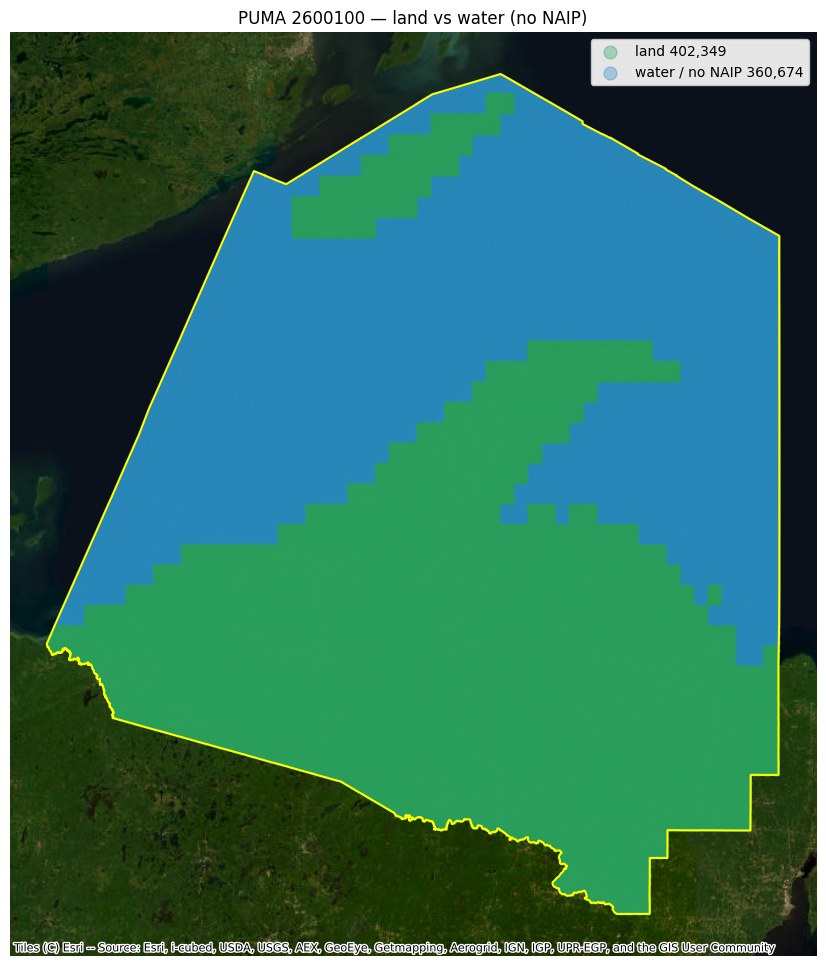

In [16]:
!pip install contextily -q
import os, geopandas as gpd, pandas as pd, matplotlib.pyplot as plt
from pyproj import Transformer
from shapely.geometry import Point, shape as shapely_shape
from shapely.ops import transform as shp_transform
from shapely.prepared import prep
import pystac_client, planetary_computer as pc
import contextily as cx
from google.colab import userdata
pc.settings.set_subscription_key(userdata.get('PC_KEY'))

BASE_DIR='/content/drive/MyDrive/michigan_unet_project'; GEO_DIR=f'{BASE_DIR}/geo'
TILE_SIZE_M, UTM_EPSG, NAIP_YEAR = 256, 26917, 2020

CODE = '2600100'      # 2601600

shp=[f'{GEO_DIR}/puma20/{f}' for f in os.listdir(f'{GEO_DIR}/puma20') if f.endswith('.shp')][0]
gp=gpd.read_file(shp); gc=next(c for c in gp.columns if c.upper().startswith('GEOID')); gp[gc]=gp[gc].astype(str)
puma_geom=gp[gp[gc]==CODE].to_crs(4326).iloc[0].geometry

# tiles
to_utm=Transformer.from_crs('EPSG:4326',f'EPSG:{UTM_EPSG}',always_xy=True).transform
to_wgs=Transformer.from_crs(f'EPSG:{UTM_EPSG}','EPSG:4326',always_xy=True).transform
g=shp_transform(to_utm,puma_geom); pg=prep(g); minx,miny,maxx,maxy=g.bounds
rows=[]; x=minx
while x<maxx:
    y=miny
    while y<maxy:
        cx_,cy_=x+TILE_SIZE_M/2,y+TILE_SIZE_M/2
        if pg.contains(Point(cx_,cy_)):
            wx,wy=to_wgs(cx_,cy_); rows.append((wx,wy))
        y+=TILE_SIZE_M
    x+=TILE_SIZE_M
gt=gpd.GeoDataFrame(pd.DataFrame(rows,columns=['lon','lat']),
                    geometry=gpd.points_from_xy([r[0] for r in rows],[r[1] for r in rows]),crs=4326)

# NAIP search + cover flag
cat=pystac_client.Client.open('https://planetarycomputer.microsoft.com/api/stac/v1',modifier=pc.sign_inplace)
items=cat.search(collections=['naip'],bbox=puma_geom.bounds,
                 datetime=f'{NAIP_YEAR}-01-01/{NAIP_YEAR}-12-31',max_items=4000).item_collection()
gi=gpd.GeoDataFrame([{'item_id':it.id,'geometry':shapely_shape(it.geometry)} for it in items],
                    geometry='geometry',crs=4326)
j=gpd.sjoin(gt,gi[['item_id','geometry']],how='left',predicate='within')
j=j[~j.index.duplicated(keep='first')]
gt['covered']=j['item_id'].notna().values
covered=gt[gt['covered']]; fallback=gt[~gt['covered']]
print(f'{CODE}: total {len(gt):,} | land {len(covered):,} | fallback {len(fallback):,} ({100*len(fallback)/len(gt):.0f}%)')

# plot over satellite
to3857=lambda df: gpd.GeoSeries(gpd.points_from_xy(df['lon'],df['lat']),crs=4326).to_crs(3857)
fb3857=to3857(fallback); cov3857=to3857(covered)
puma3857=gpd.GeoSeries([puma_geom],crs=4326).to_crs(3857)

fig,ax=plt.subplots(figsize=(12,12))
puma3857.boundary.plot(ax=ax,color='yellow',linewidth=1.5)

ax.scatter(cov3857.x,cov3857.y,s=0.6,c='#2ca25f',alpha=0.35,label=f'land {len(covered):,}')
ax.scatter(fb3857.x, fb3857.y, s=0.6,c='#2b8cbe',alpha=0.35,label=f'water / no NAIP {len(fallback):,}')
cx.add_basemap(ax,source=cx.providers.Esri.WorldImagery,crs=3857)
ax.set_title(f'PUMA {CODE} — land vs water (no NAIP)')
ax.legend(markerscale=12, framealpha=0.9)
ax.set_aspect('equal'); ax.axis('off')
plt.savefig(f'{BASE_DIR}/results_9puma/predictions_puma/fallback_satellite_{CODE}.png',dpi=150,bbox_inches='tight')
plt.show()

2601600: total 183,351 | land 116,954 | fallback 66,397 (36%)


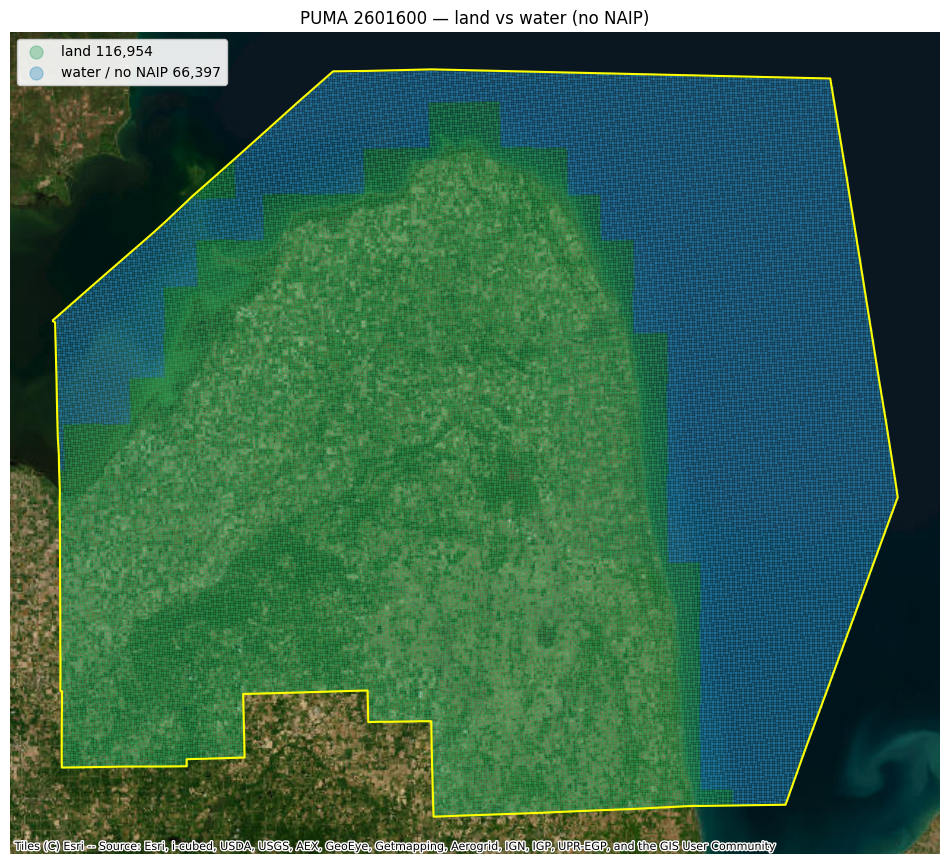

In [14]:
!pip install contextily -q
import os, geopandas as gpd, pandas as pd, matplotlib.pyplot as plt
from pyproj import Transformer
from shapely.geometry import Point, shape as shapely_shape
from shapely.ops import transform as shp_transform
from shapely.prepared import prep
import pystac_client, planetary_computer as pc
import contextily as cx
from google.colab import userdata
pc.settings.set_subscription_key(userdata.get('PC_KEY'))

BASE_DIR='/content/drive/MyDrive/michigan_unet_project'; GEO_DIR=f'{BASE_DIR}/geo'
TILE_SIZE_M, UTM_EPSG, NAIP_YEAR = 256, 26917, 2020

CODE = '2601600'      # 2601600

shp=[f'{GEO_DIR}/puma20/{f}' for f in os.listdir(f'{GEO_DIR}/puma20') if f.endswith('.shp')][0]
gp=gpd.read_file(shp); gc=next(c for c in gp.columns if c.upper().startswith('GEOID')); gp[gc]=gp[gc].astype(str)
puma_geom=gp[gp[gc]==CODE].to_crs(4326).iloc[0].geometry

# tiles
to_utm=Transformer.from_crs('EPSG:4326',f'EPSG:{UTM_EPSG}',always_xy=True).transform
to_wgs=Transformer.from_crs(f'EPSG:{UTM_EPSG}','EPSG:4326',always_xy=True).transform
g=shp_transform(to_utm,puma_geom); pg=prep(g); minx,miny,maxx,maxy=g.bounds
rows=[]; x=minx
while x<maxx:
    y=miny
    while y<maxy:
        cx_,cy_=x+TILE_SIZE_M/2,y+TILE_SIZE_M/2
        if pg.contains(Point(cx_,cy_)):
            wx,wy=to_wgs(cx_,cy_); rows.append((wx,wy))
        y+=TILE_SIZE_M
    x+=TILE_SIZE_M
gt=gpd.GeoDataFrame(pd.DataFrame(rows,columns=['lon','lat']),
                    geometry=gpd.points_from_xy([r[0] for r in rows],[r[1] for r in rows]),crs=4326)

# NAIP search + cover flag
cat=pystac_client.Client.open('https://planetarycomputer.microsoft.com/api/stac/v1',modifier=pc.sign_inplace)
items=cat.search(collections=['naip'],bbox=puma_geom.bounds,
                 datetime=f'{NAIP_YEAR}-01-01/{NAIP_YEAR}-12-31',max_items=4000).item_collection()
gi=gpd.GeoDataFrame([{'item_id':it.id,'geometry':shapely_shape(it.geometry)} for it in items],
                    geometry='geometry',crs=4326)
j=gpd.sjoin(gt,gi[['item_id','geometry']],how='left',predicate='within')
j=j[~j.index.duplicated(keep='first')]
gt['covered']=j['item_id'].notna().values
covered=gt[gt['covered']]; fallback=gt[~gt['covered']]
print(f'{CODE}: total {len(gt):,} | land {len(covered):,} | fallback {len(fallback):,} ({100*len(fallback)/len(gt):.0f}%)')

# plot over satellite
to3857=lambda df: gpd.GeoSeries(gpd.points_from_xy(df['lon'],df['lat']),crs=4326).to_crs(3857)
fb3857=to3857(fallback); cov3857=to3857(covered)
puma3857=gpd.GeoSeries([puma_geom],crs=4326).to_crs(3857)

fig,ax=plt.subplots(figsize=(12,12))
puma3857.boundary.plot(ax=ax,color='yellow',linewidth=1.5)

ax.scatter(cov3857.x,cov3857.y,s=0.6,c='#2ca25f',alpha=0.35,label=f'land {len(covered):,}')
ax.scatter(fb3857.x, fb3857.y, s=0.6,c='#2b8cbe',alpha=0.35,label=f'water / no NAIP {len(fallback):,}')
cx.add_basemap(ax,source=cx.providers.Esri.WorldImagery,crs=3857)
ax.set_title(f'PUMA {CODE} — land vs water (no NAIP)')
ax.legend(markerscale=12, framealpha=0.9)
ax.set_aspect('equal'); ax.axis('off')
plt.savefig(f'{BASE_DIR}/results_9puma/predictions_puma/fallback_satellite_{CODE}.png',dpi=150,bbox_inches='tight')
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


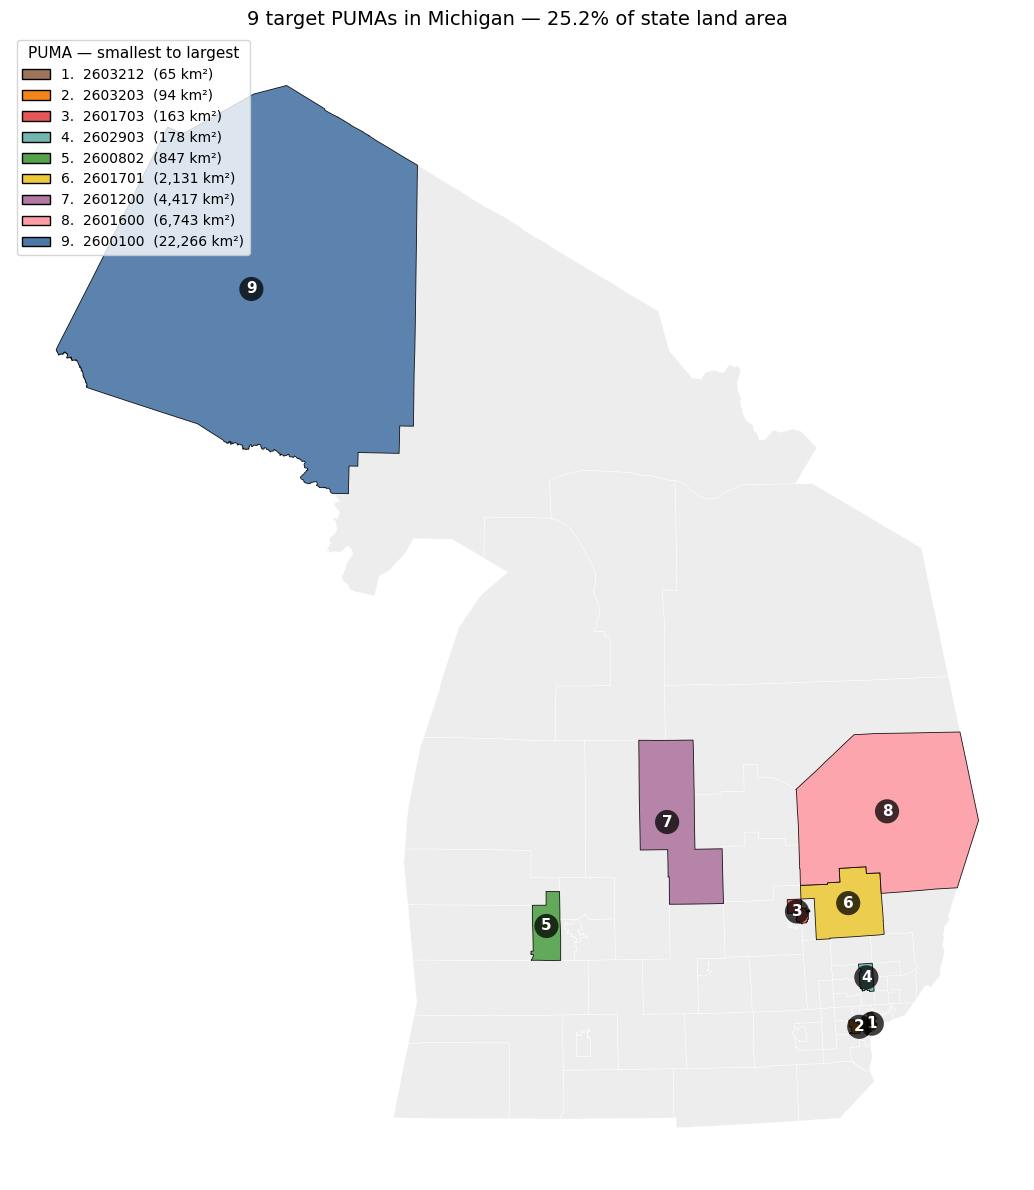

9 PUMAs cover ~25.2% of Michigan land area
Saved -> /content/drive/MyDrive/michigan_unet_project/results_9puma/predictions_puma/puma_coverage_map.png


In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, urllib.request
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

BASE_DIR = '/content/drive/MyDrive/michigan_unet_project'
GEO_DIR  = f'{BASE_DIR}/geo'
PRED_DIR = f'{BASE_DIR}/results_9puma/predictions_puma'

PUMAS_9 = ['2600100', '2600802', '2601200', '2601600', '2601701',
           '2601703', '2602903', '2603203', '2603212']

# --- load all Michigan PUMAs (cached if already downloaded) ---
PUMA_DIR = f'{GEO_DIR}/puma20'
os.makedirs(PUMA_DIR, exist_ok=True)
if not any(f.endswith('.shp') for f in os.listdir(PUMA_DIR)):
    for url in ['https://www2.census.gov/geo/tiger/TIGER2023/PUMA20/tl_2023_26_puma20.zip',
                'https://www2.census.gov/geo/tiger/TIGER2022/PUMA20/tl_2022_26_puma20.zip']:
        try:
            urllib.request.urlretrieve(url, f'{PUMA_DIR}/p.zip')
            with zipfile.ZipFile(f'{PUMA_DIR}/p.zip') as z: z.extractall(PUMA_DIR)
            break
        except Exception as e:
            print('failed', url, e)

shp = [f'{PUMA_DIR}/{f}' for f in os.listdir(PUMA_DIR) if f.endswith('.shp')][0]
gdf = gpd.read_file(shp).to_crs(epsg=3078)
gcol = next(c for c in gdf.columns if c.upper().startswith('GEOID'))
acol = next((c for c in gdf.columns if c.upper().startswith('ALAND')), None)
gdf[gcol] = gdf[gcol].astype(str)

nine = gdf[gdf[gcol].isin(PUMAS_9)].copy()

# --- number by land area, smallest = 1 ---
nine['area_km2'] = (nine[acol] / 1e6) if acol else (nine.geometry.area / 1e6)
nine = nine.sort_values('area_km2').reset_index(drop=True)   # ascending -> #1 smallest

# --- coverage % of Michigan land area ---
if acol:
    cov = 100 * nine[acol].sum() / gdf[acol].sum()
else:
    cov = 100 * nine.geometry.area.sum() / gdf.geometry.area.sum()

# --- plot ---
fig, ax = plt.subplots(figsize=(11, 12))
gdf.plot(ax=ax, color='#ededed', edgecolor='white', linewidth=0.3)
#cmap = plt.cm.tab10
colors = [
    "#9D755D", "#F58518", "#E45756",
    "#72B7B2", "#54A24B", "#EECA3B",
    "#B279A2", "#FF9DA6", "#4C78A8"
]
nine.plot(
    ax=ax,
    color=colors[:len(nine)],
    edgecolor='black',
    linewidth=0.6,
    alpha=0.9
)

for i, row in nine.iterrows():
    p = row.geometry.representative_point()
    ax.annotate(str(i + 1), (p.x, p.y), ha='center', va='center',
                fontsize=11, fontweight='bold', color='white',
                bbox=dict(boxstyle='circle', fc='black', ec='none', alpha=0.75))

handles = [Patch(facecolor=colors[i % len(colors)], edgecolor='black',
                 label=f'{i+1}.  {row[gcol]}  ({row["area_km2"]:,.0f} km²)')
           for i, row in nine.iterrows()]
ax.legend(handles=handles, title='PUMA — smallest to largest', loc='upper left',
          fontsize=10, title_fontsize=11, frameon=True)

ax.set_title(f'9 target PUMAs in Michigan — {cov:.1f}% of state land area', fontsize=14)
ax.axis('off')
plt.tight_layout()

out = f'{PRED_DIR}/puma_coverage_map.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()

print(f'9 PUMAs cover ~{cov:.1f}% of Michigan land area')
print('Saved ->', out)